In [145]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

In [146]:
df = pd.read_csv('BBCA_2021-01-01_sd_2026-01-01.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

## Data Understanding

### Pengecekan Informasi Data

In [ ]:
start_date = df['date'].min()
end_date = df['date'].max()
total_days = (end_date - start_date).days

print(f"Tanggal Awal Data  : {start_date.strftime('%Y-%m-%d')}")
print(f"Tanggal Akhir Data : {end_date.strftime('%Y-%m-%d')}")
print(f"Total Rentang Waktu: {total_days} Hari Kalender")
print(f"Total Hari Perdagangan Aktif: {len(df)} Hari Kerja")

In [147]:
df.head()

,symbol,date,open,high,low,close,volume
0,BBCA,2021-01-04,6800,6855,6720,6835,353120000
1,BBCA,2021-01-05,6860,7090,6850,7090,104831000
2,BBCA,2021-01-06,7050,7075,6880,6945,89753504
3,BBCA,2021-01-07,7000,7050,6910,6965,71360000
4,BBCA,2021-01-08,7035,7080,6975,7050,75033504


### Pengecekan Data Hilang

In [148]:
print(df.isna().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


### Visualisasi Harga

In [ ]:
df_idx = df.set_index('date')

plt.figure(figsize=(12, 6))
plt.plot(df_idx['open'], label='Open', color='blue', alpha=0.7)
plt.plot(df_idx['close'], label='Close', color='orange', alpha=0.7)
plt.title('Tren Pergerakan Harga Saham BBCA (Open vs Close)')
plt.xlabel('Tahun')
plt.ylabel('Harga (Rupiah)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Data Preparation

### Pembagian Data Latih dan Uji

In [150]:
TRAIN_SIZE_RATIO = 0.9

train_size = int(len(df) * TRAIN_SIZE_RATIO)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print(f"Jumlah Data Train : {len(train_df)}")
print(f"Jumlah Data Test  : {len(test_df)}")

Jumlah Data Train : 1134
Jumlah Data Test  : 126


### Dekomposisi Seasonal

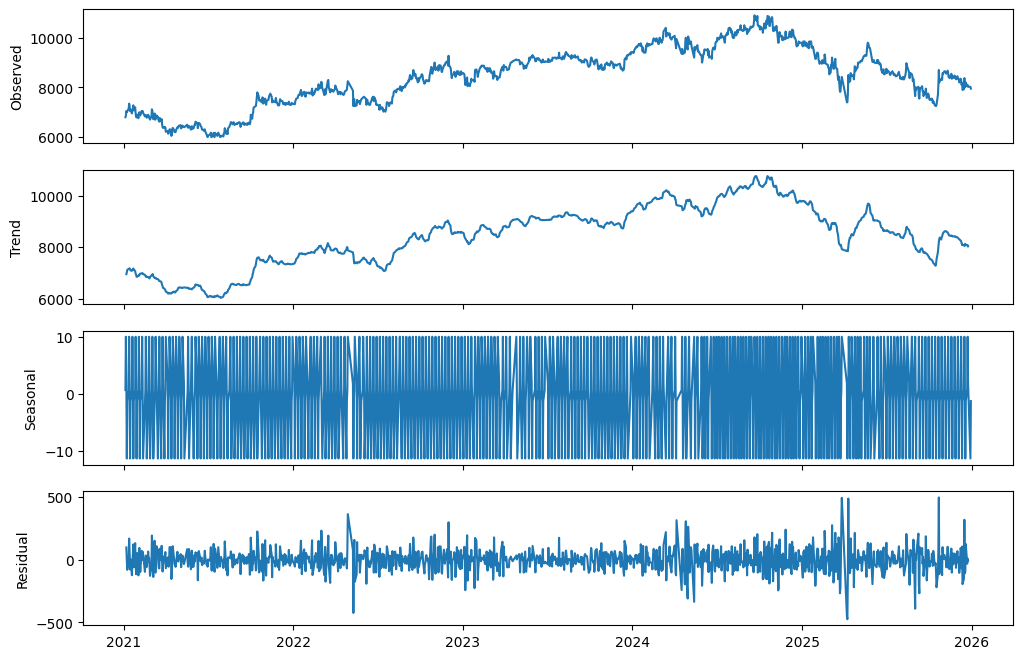

In [151]:
decomposition = seasonal_decompose(df_idx['open'], model='additive', period=5)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residual')
plt.show()

## Modelling & Evaluation

In [152]:
train_y = train_df['open'].values

In [153]:
train_y = train_df['open'].values
test_y = test_df['open'].values

### Model ARIMA

In [154]:
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_arima_mape = float("inf")
best_arima_order = None
arima_results = []

In [155]:
for param in pdq:
    try:
        model = ARIMA(train_y, order=param)
        res = model.fit()
        forecast = res.forecast(steps=len(test_y))

        mse = mean_squared_error(test_y, forecast)
        mape = np.mean(np.abs((test_y - forecast) / test_y)) * 100

        arima_results.append({'order': param, 'MSE': mse, 'MAPE': mape})

        if mape < best_arima_mape:
            best_arima_mape = mape
            best_arima_order = param
    except Exception:
        continue

In [156]:
arima_results_df = pd.DataFrame(arima_results).sort_values(by='MAPE')
arima_results_df.head()

,order,MSE,MAPE
1,"(0, 0, 1)",249595.060352,4.560031
0,"(0, 0, 0)",249700.427692,4.565073
2,"(0, 0, 2)",249752.510535,4.567821
20,"(2, 0, 2)",370024.702939,5.998684
11,"(1, 0, 2)",371277.095891,6.009940


### Model SARIMA

In [157]:
p = d = q = range(0, 3)
P = D = Q = range(0, 3)
s = 5

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], s) for x in list(itertools.product(P, D, Q))]

best_sarima_mape = float("inf")
best_sarima_order = None
best_sarima_seasonal = None
sarima_results = []

In [ ]:
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(
                train_y,
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)
            forecast = res.forecast(steps=len(test_y))

            mse = mean_squared_error(test_y, forecast)
            mape = np.mean(np.abs((test_y - forecast) / test_y)) * 100

            sarima_results.append({
                'order': param,
                'seasonal_order': param_seasonal,
                'MSE': mse,
                'MAPE': mape
            })

            if mape < best_sarima_mape:
                best_sarima_mape = mape
                best_sarima_order = param
                best_sarima_seasonal = param_seasonal
        except Exception:
            continue

In [ ]:
sarima_results_df = pd.DataFrame(sarima_results).sort_values(by='MAPE')
sarima_results_df.head()

### Visualisasi Hasil

In [ ]:
model_arima = ARIMA(train_y, order=best_arima_order)
res_arima = model_arima.fit()

forecast_arima = res_arima.forecast(steps=len(test_y))

plt.figure(figsize=(10, 5))
plt.plot(train_df['date'], train_df['open'], color='blue', label='Train Data')
plt.plot(test_df['date'], test_df['open'], color='green', label='Test Data')
plt.plot(test_df['date'], forecast_arima, color='yellow', label='Forecast')
plt.title(f'Forecast ARIMA {best_arima_order}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
model_sarima = sm.tsa.statespace.SARIMAX(
    train_y,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal
)
res_sarima = model_sarima.fit(disp=False)

forecast_sarima = res_sarima.forecast(steps=len(test_y))

plt.figure(figsize=(10, 5))
plt.plot(train_df['date'], train_df['open'], color='blue', label='Train Data')
plt.plot(test_df['date'], test_df['open'], color='green', label='Test Data')
plt.plot(test_df['date'], forecast_sarima, color='yellow', label='Forecast')
plt.title(f'Forecast SARIMA {best_sarima_order}x{best_sarima_seasonal}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()